Authenticated using refresh token.
0:00:00 Job 'j-250813124017406db3921d8027991124': send 'start'
0:00:14 Job 'j-250813124017406db3921d8027991124': created (progress 0%)
0:00:20 Job 'j-250813124017406db3921d8027991124': created (progress 0%)
0:00:26 Job 'j-250813124017406db3921d8027991124': created (progress 0%)
0:00:34 Job 'j-250813124017406db3921d8027991124': created (progress 0%)
0:00:44 Job 'j-250813124017406db3921d8027991124': created (progress 0%)
0:00:56 Job 'j-250813124017406db3921d8027991124': running (progress N/A)
0:01:12 Job 'j-250813124017406db3921d8027991124': running (progress N/A)
0:01:31 Job 'j-250813124017406db3921d8027991124': running (progress N/A)
0:01:55 Job 'j-250813124017406db3921d8027991124': finished (progress 100%)


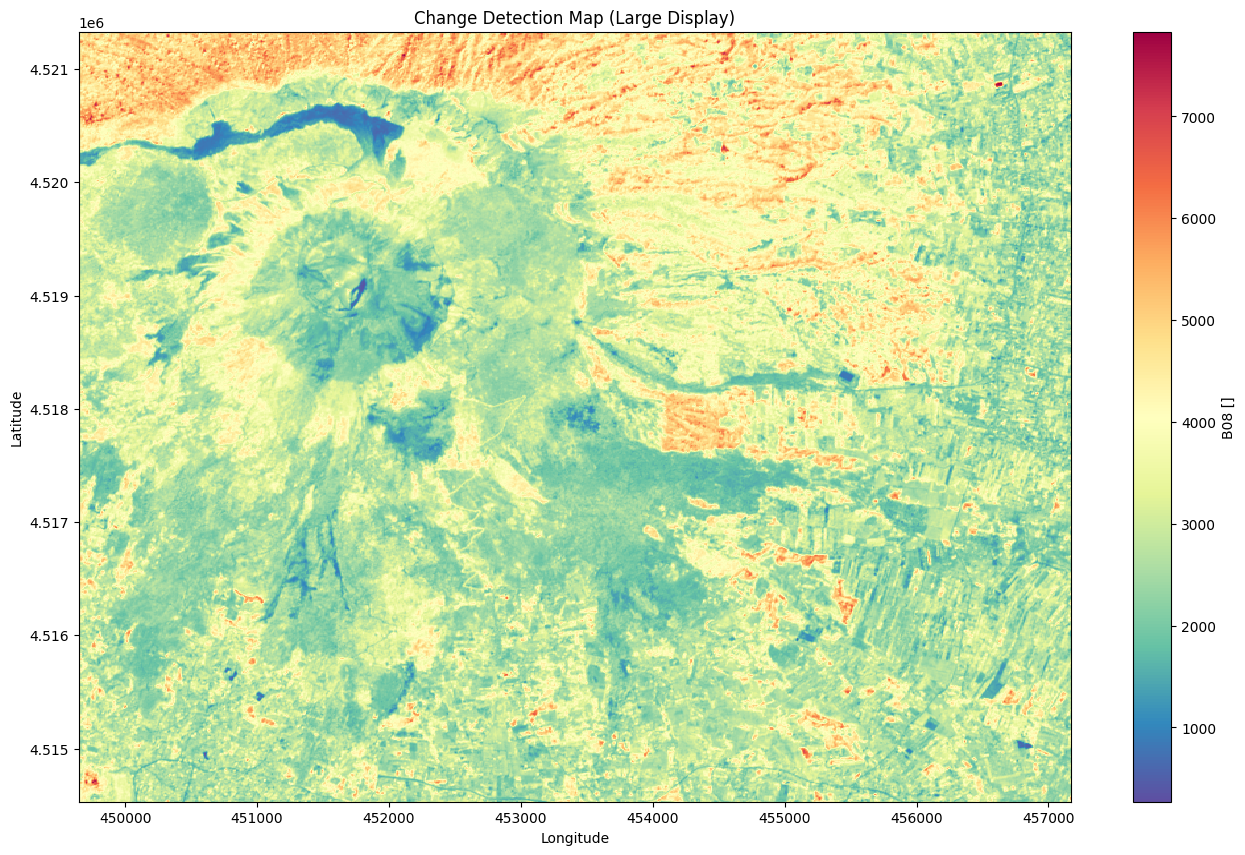

In [8]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt



connection = openeo.connect(
    url="openeo.dataspace.copernicus.eu",
)
connection.authenticate_oidc()


spatial_extent = {"type":"Polygon","coordinates":[[[14.403386,40.841391],[14.49191,40.841391],[14.49191,40.780683],[14.403386,40.780683],[14.403386,40.841391]]]}

s2_archive = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2025-06-04", "2025-06-06"],
    bands=["B08"]
)


s2_crisis = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2025-08-08", "2025-08-10"],
    bands=["B08"],
)

#difference_map = s2_archive.subtract(s2_crisis)
difference_map = s2_crisis.subtract(s2_archive)

# To visualize the difference map

difference_map.execute_batch("change_difference_map.nc",title="change_difference_map")

ds = xr.load_dataset("change_difference_map.nc")




plt.figure(figsize=(16, 10))
ds.B08.isel(t=0).plot.imshow(cmap='Spectral_r')
plt.title("Change Detection Map (Large Display)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# delta Normalized Burn Ratio (dNBR)

In [5]:
import openeo
import xarray as xr
import matplotlib.pyplot as plt
import re


In [ ]:



connection = openeo.connect(
    url="openeo.dataspace.copernicus.eu",
)
connection.authenticate_oidc()

spatial_extent = {"type":"Polygon","coordinates":[[[14.349177,40.857812],[14.49438,40.857812],[14.49438,40.743689],[14.349177,40.743689],[14.349177,40.857812]]]}

s2_archive = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2025-07-24", "2025-07-26"],
    bands=["B08","B12"]
)


s2_crisis = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent = spatial_extent  ,
    temporal_extent=["2025-08-13", "2025-08-15"],
    bands=["B08","B12"],
)

b8 = s2_archive.band("B08")
b12 = s2_archive.band("B12")
NBR_archive = (b8 - b12) / (b8 + b12)

b8 = s2_crisis.band("B08")
b12 = s2_crisis.band("B12")
NBR_crisis = (b8 - b12) / (b8 + b12)

NBR_archive.execute_batch("NBR_archive.nc",title="change_dNBR", format="netCDF")
NBR_crisis.execute_batch("NBR_crisis.nc",title="change_dNBR", format="netCDF")


In [6]:


ds_NBR_archive = xr.load_dataset("NBR_archive.nc")
ds_NBR_crisis = xr.load_dataset("NBR_crisis.nc")

spatial_ref = ds_NBR_crisis.crs.attrs['spatial_ref']

# Usa una regex per trovare i codici EPSG all'interno della stringa WKT
epsg_codes = re.findall(r'AUTHORITY\["EPSG",\s*"(\d+)"\]', spatial_ref)

difference_map = ds_NBR_archive['var'].values - ds_NBR_crisis['var'].values
difference = xr.DataArray(difference_map, coords={ 't': ds_NBR_crisis.t.values,'x': ds_NBR_crisis.x.values, 'y': ds_NBR_crisis.y.values, 
                               },
             dims=['t', 'y', 'x'],attrs=ds_NBR_crisis.attrs)


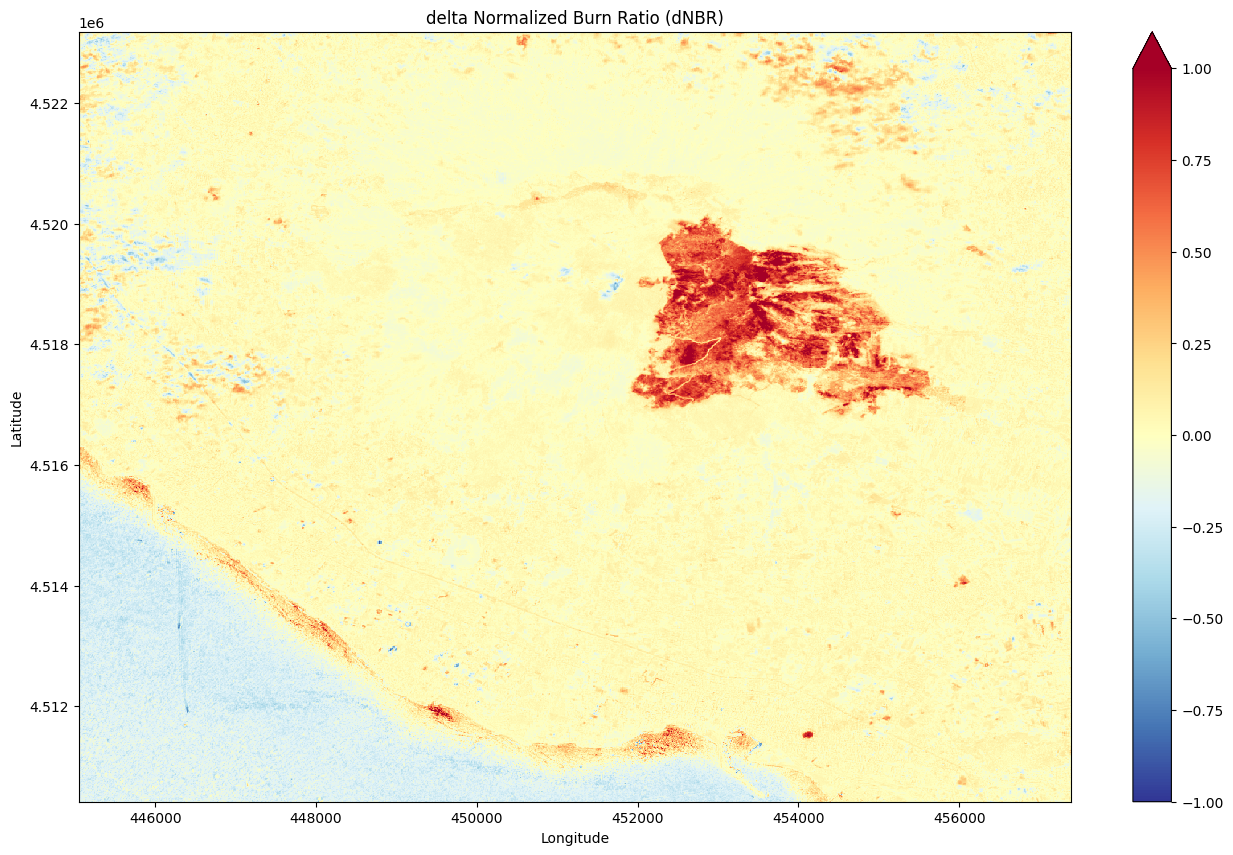

In [14]:
plt.figure(figsize=(16, 10))
difference.isel(t=0).plot.imshow(cmap='RdYlBu_r',vmin=-1, vmax=1, add_colorbar=True)
plt.title("delta Normalized Burn Ratio (dNBR)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [2]:
6154976/1000000

6.154976

In [5]:
ds_NBR_crisis

<xarray.Dataset> Size: 2MB
Dimensions:  (t: 1, x: 752, y: 680)
Coordinates:
  * t        (t) datetime64[ns] 8B 2025-08-09
  * x        (x) float64 6kB 4.497e+05 4.497e+05 ... 4.572e+05 4.572e+05
  * y        (y) float64 5kB 4.521e+06 4.521e+06 ... 4.515e+06 4.515e+06
Data variables:
    crs      |S1 1B b''
    var      (t, y, x) float32 2MB 0.7333 0.7205 0.7405 0.7242 ... nan nan nan
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.66.0a10.dev2...
    description:  
    title:

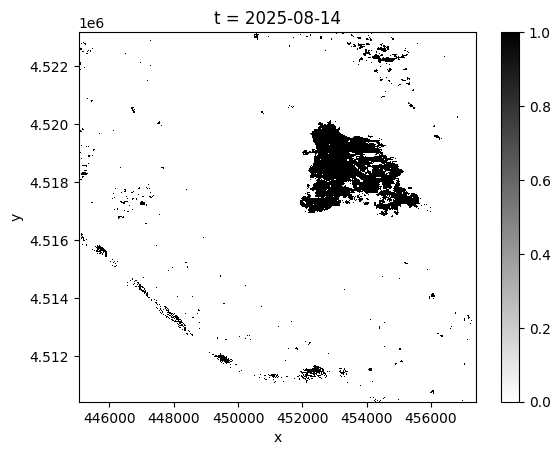

In [2]:
threshold = 0.25  # Soglia di esempio, da adattare in base ai tuoi dati

# Crea la maschera di inondazione
dNBR_mask = (difference > threshold).astype(int)
dNBR_mask.plot(cmap='binary')

### Convert dNBR_mask in geoDataframe

In [3]:
import geopandas as gpd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape

# Convert dNBR_mask to polygons (features)
mask = dNBR_mask.squeeze().values.astype('uint8')  # remove time dim if present
transform = rasterio.transform.from_bounds(
    float(dNBR_mask.x.min()), float(dNBR_mask.y.min()),
    float(dNBR_mask.x.max()), float(dNBR_mask.y.max()),
    dNBR_mask.sizes['x'], dNBR_mask.sizes['y']
)

polygons = []
values = []
for geom, val in shapes(mask, mask=mask.astype(bool), transform=transform):
    if val == 1:
        polygons.append(shape(geom))
        values.append(val)

gdf = gpd.GeoDataFrame({'geometry': polygons, 'value': values})


# Imposta il sistema di coordinate originale (ad esempio EPSG:32632 per UTM zone 32N)
gdf.set_crs(epsg=int(epsg_codes[-1]), inplace=True)
# Calcola l'area in m²
gdf['area_m2'] = gdf.area 

# Trasforma il GeoDataFrame in WGS84
gdf_wgs84 = gdf.to_crs(epsg=4326)
gdf_wgs84['area_m2'] = gdf['area_m2']  # Mantieni la colonna area_km2

# Salva il GeoDataFrame in formato GeoJSON
gdf_wgs84.to_file("dNBR_mask.geojson", driver='GeoJSON')

In [4]:
gdf_wgs84

,geometry,value,area_m2
0,"POLYGON ((14.34808 40.85779, 14.34808 40.8577,...",1.0,99.840656
1,"POLYGON ((14.40914 40.85812, 14.40914 40.85803...",1.0,99.840656
2,"POLYGON ((14.42336 40.85819, 14.42336 40.85801...",1.0,199.681313
3,"POLYGON ((14.42407 40.85819, 14.42407 40.85801...",1.0,199.681313
4,"POLYGON ((14.4562 40.85826, 14.4562 40.85817, ...",1.0,99.840656
...,...,...,...
1732,"POLYGON ((14.46234 40.74388, 14.46234 40.74379...",1.0,99.840656
1733,"POLYGON ((14.45914 40.74387, 14.45914 40.74378...",1.0,299.521969
1734,"POLYGON ((14.46435 40.74371, 14.46435 40.74362...",1.0,99.840656
1735,"POLYGON ((14.45832 40.74377, 14.45832 40.74368...",1.0,599.043938
